In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

current_dir = Path.cwd()

if (current_dir / "data").exists():
    project_root = current_dir
elif (current_dir.parent / "data").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError(
        f"Cannot find project root. Current directory: {current_dir}"
    )

print("Current directory:", current_dir)
print("Project root:", project_root)

Current directory: /Users/zhouzhou/Desktop/dst-review-analysis/notebooks
Project root: /Users/zhouzhou/Desktop/dst-review-analysis


In [2]:
all_data_path = (
    project_root
    / "data"
    / "processed"
    / "dst_reviews_cleaned_all.csv"
)

english_text_path = (
    project_root
    / "data"
    / "processed"
    / "dst_reviews_english_text.csv"
)

all_df = pd.read_csv(all_data_path)
text_df = pd.read_csv(english_text_path)

print("All cleaned data:", all_df.shape)
print("English text data:", text_df.shape)

All cleaned data: (4974, 28)
English text data: (4511, 29)


In [3]:
all_df.head()

,recommendation_id,language,review,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,timestamp_created,timestamp_updated,playtime_forever_minutes,playtime_at_review_minutes,num_games_owned,author_num_reviews,created_at,updated_at,playtime_forever_hours,playtime_at_review_hours,review_date,review_year,review_month,review_length_chars,review_word_count,review_length_category,detected_language
0,232146949,english,Klei Entertainment was whippin' up actual shi in a kettle. Boiling shi in a kettle. He was whippin' up actual poo in...,False,0,0,0.5,0,False,False,False,1785965086,1785965086,265.0,265.0,110,29,2026-08-05 21:24:46+00:00,2026-08-05 21:24:46+00:00,4.416667,4.416667,2026-08-05,2026,2026-08,162,31,Medium,en
1,232134193,english,So much content! When you get over the starting hurdle of surviving its so fun to explore and find out what everythi...,True,0,0,0.5,0,False,False,False,1785952590,1785952590,15951.0,15621.0,0,1,2026-08-05 17:56:30+00:00,2026-08-05 17:56:30+00:00,265.850000,260.350000,2026-08-05,2026,2026-08,121,23,Medium,en
2,232131462,english,Pretty good game is a bit hard for new players so its best if youre starting out to look some stuff up or have a fri...,True,0,0,0.5,0,False,True,False,1785949854,1785949854,814.0,515.0,9,2,2026-08-05 17:10:54+00:00,2026-08-05 17:10:54+00:00,13.566667,8.583333,2026-08-05,2026,2026-08,133,28,Medium,en
3,232125450,english,Мне понравилась игра очень веселая с друзьями особенно но печально что поиграли всего два раза но всем рекомендую,True,0,0,0.5,0,True,False,False,1785944379,1785944379,267.0,267.0,0,1,2026-08-05 15:39:39+00:00,2026-08-05 15:39:39+00:00,4.450000,4.450000,2026-08-05,2026,2026-08,113,18,Short,ru
4,232114765,english,awesome game!,True,0,0,0.5,0,True,False,False,1785934292,1785934292,1793.0,1564.0,268,52,2026-08-05 12:51:32+00:00,2026-08-05 12:51:32+00:00,29.883333,26.066667,2026-08-05,2026,2026-08,13,2,Very short,unknown_short


In [4]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4974 entries, 0 to 4973
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   recommendation_id            4974 non-null   int64  
 1   language                     4974 non-null   object 
 2   review                       4974 non-null   object 
 3   voted_up                     4974 non-null   bool   
 4   votes_up                     4974 non-null   int64  
 5   votes_funny                  4974 non-null   int64  
 6   weighted_vote_score          4974 non-null   float64
 7   comment_count                4974 non-null   int64  
 8   steam_purchase               4974 non-null   bool   
 9   received_for_free            4974 non-null   bool   
 10  written_during_early_access  4974 non-null   bool   
 11  timestamp_created            4974 non-null   int64  
 12  timestamp_updated            4974 non-null   int64  
 13  playtime_forever_m

In [5]:
date_columns = [
    "created_at",
    "updated_at",
]

for column in date_columns:
    if column in all_df.columns:
        all_df[column] = pd.to_datetime(
            all_df[column],
            utc=True,
            errors="coerce",
        )

    if column in text_df.columns:
        text_df[column] = pd.to_datetime(
            text_df[column],
            utc=True,
            errors="coerce",
        )

print("created_at type:", all_df["created_at"].dtype)
print("Invalid created dates:", all_df["created_at"].isna().sum())
print("Earliest review:", all_df["created_at"].min())
print("Latest review:", all_df["created_at"].max())

created_at type: datetime64[ns, UTC]
Invalid created dates: 0
Earliest review: 2025-11-25 14:26:05+00:00
Latest review: 2026-08-05 21:24:46+00:00


In [6]:
def convert_to_boolean(series):
    """Convert common true/false values to pandas BooleanDtype."""

    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")

    cleaned_series = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    value_mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    return cleaned_series.map(value_mapping).astype("boolean")


boolean_columns = [
    "voted_up",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
]

for column in boolean_columns:
    if column in all_df.columns:
        all_df[column] = convert_to_boolean(all_df[column])

    if column in text_df.columns:
        text_df[column] = convert_to_boolean(text_df[column])

print(all_df[boolean_columns].dtypes)

voted_up                       boolean
steam_purchase                 boolean
received_for_free              boolean
written_during_early_access    boolean
dtype: object


In [7]:
key_columns = [
    "recommendation_id",
    "review",
    "voted_up",
    "created_at",
    "playtime_at_review_hours",
    "playtime_forever_hours",
    "votes_up",
    "review_word_count",
]

quality_check = pd.DataFrame(
    {
        "data_type": all_df[key_columns].dtypes.astype(str),
        "missing_count": all_df[key_columns].isna().sum(),
        "missing_rate_percent": (
            all_df[key_columns].isna().mean() * 100
        ).round(2),
    }
)

quality_check

,data_type,missing_count,missing_rate_percent
recommendation_id,int64,0,0.0
review,object,0,0.0
voted_up,boolean,0,0.0
created_at,"datetime64[ns, UTC]",0,0.0
playtime_at_review_hours,float64,0,0.0
playtime_forever_hours,float64,0,0.0
votes_up,int64,0,0.0
review_word_count,int64,0,0.0


In [8]:
total_reviews = len(all_df)
positive_reviews = int(all_df["voted_up"].sum())
negative_reviews = int(
    all_df["voted_up"].eq(False).sum()
)

summary_metrics = pd.Series(
    {
        "Total reviews": total_reviews,
        "Recommended reviews": positive_reviews,
        "Not recommended reviews": negative_reviews,
        "Positive rate (%)": (
            positive_reviews / total_reviews * 100
        ),
        "Median playtime at review (hours)": (
            all_df["playtime_at_review_hours"].median()
        ),
        "Median total playtime (hours)": (
            all_df["playtime_forever_hours"].median()
        ),
        "Median review word count": (
            all_df["review_word_count"].median()
        ),
        "Average helpful votes": (
            all_df["votes_up"].mean()
        ),
    }
)

summary_metrics.round(2)

Total reviews                        4974.00
Recommended reviews                  4512.00
Not recommended reviews               462.00
Positive rate (%)                      90.71
Median playtime at review (hours)      29.38
Median total playtime (hours)          46.82
Median review word count                7.00
Average helpful votes                   0.63
dtype: float64

In [9]:
dataset_comparison = pd.DataFrame(
    {
        "Dataset": [
            "All cleaned reviews",
            "English text reviews",
        ],
        "Review count": [
            len(all_df),
            len(text_df),
        ],
        "Positive rate (%)": [
            all_df["voted_up"].mean() * 100,
            text_df["voted_up"].mean() * 100,
        ],
    }
)

dataset_comparison["Positive rate (%)"] = (
    dataset_comparison["Positive rate (%)"]
    .round(2)
)

dataset_comparison

,Dataset,Review count,Positive rate (%)
0,All cleaned reviews,4974,90.71
1,English text reviews,4511,90.73


In [10]:
review_distribution = pd.Series(
    {
        "Recommended": int(all_df["voted_up"].eq(True).sum()),
        "Not recommended": int(all_df["voted_up"].eq(False).sum()),
    }
)

review_distribution

Recommended        4512
Not recommended     462
dtype: int64

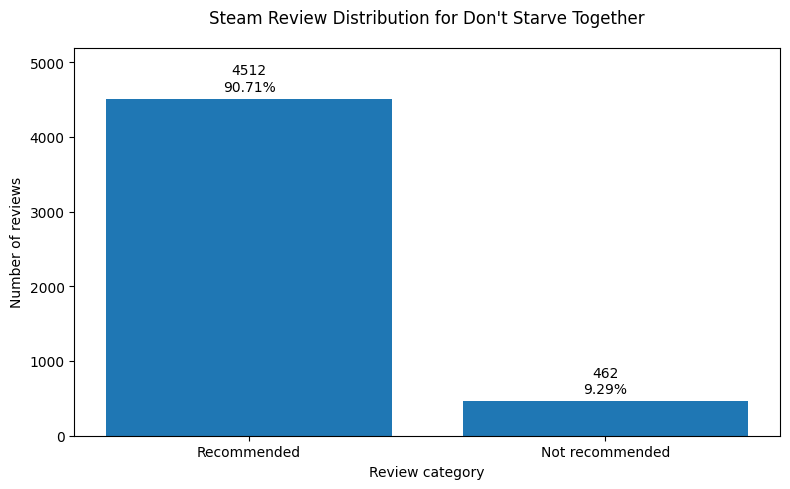

In [11]:
figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(8, 5))

bars = axis.bar(
    review_distribution.index,
    review_distribution.values,
)

axis.set_title(
    "Steam Review Distribution for Don't Starve Together",
    pad=18,
)
axis.set_xlabel("Review category")
axis.set_ylabel("Number of reviews")

total = review_distribution.sum()
maximum_value = review_distribution.max()

axis.set_ylim(0, maximum_value * 1.15)

for bar, value in zip(bars, review_distribution.values):
    percentage = value / total * 100

    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maximum_value * 0.015,
        f"{value}\n{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "01_review_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

该数据集包含4,974条有效的Steam评论，其中4,512条为正面评价，462条为负面评价，整体正面评价率为90.71%。
分布严重失衡，因为负面评论仅占样本的9.29%。在构建和评估后续的文本分类模型时，应考虑这一不平衡情况。

In [12]:
all_df["review_month"] = (
    all_df["created_at"]
    .dt.tz_convert(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_summary = (
    all_df.groupby(
        "review_month",
        as_index=False,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        positive_reviews=(
            "voted_up",
            "sum",
        ),
        positive_rate=(
            "voted_up",
            "mean",
        ),
    )
)

monthly_summary

,review_month,review_count,positive_reviews,positive_rate
0,2025-11-01,409,403,0.98533
1,2025-12-01,526,477,0.906844
2,2026-01-01,452,406,0.89823
3,2026-02-01,440,394,0.895455
4,2026-03-01,411,374,0.909976
5,2026-04-01,553,504,0.911392
6,2026-05-01,454,409,0.900881
7,2026-06-01,890,800,0.898876
8,2026-07-01,777,691,0.889318
9,2026-08-01,62,54,0.870968


In [13]:
print("Number of months:", len(monthly_summary))

print(
    "Total reviews in monthly summary:",
    monthly_summary["review_count"].sum(),
)

monthly_summary[
    [
        "review_month",
        "review_count",
        "positive_reviews",
        "positive_rate",
    ]
]

Number of months: 10
Total reviews in monthly summary: 4974


,review_month,review_count,positive_reviews,positive_rate
0,2025-11-01,409,403,0.98533
1,2025-12-01,526,477,0.906844
2,2026-01-01,452,406,0.89823
3,2026-02-01,440,394,0.895455
4,2026-03-01,411,374,0.909976
5,2026-04-01,553,504,0.911392
6,2026-05-01,454,409,0.900881
7,2026-06-01,890,800,0.898876
8,2026-07-01,777,691,0.889318
9,2026-08-01,62,54,0.870968


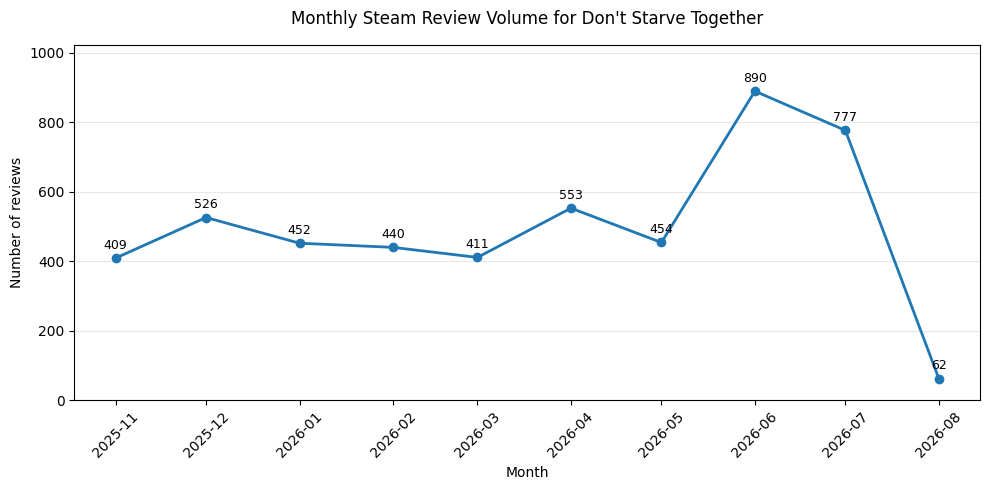

In [14]:
figure, axis = plt.subplots(figsize=(10, 5))

axis.plot(
    monthly_summary["review_month"],
    monthly_summary["review_count"],
    marker="o",
    linewidth=2,
)

axis.set_title(
    "Monthly Steam Review Volume for Don't Starve Together",
    pad=15,
)
axis.set_xlabel("Month")
axis.set_ylabel("Number of reviews")
axis.tick_params(
    axis="x",
    rotation=45,
)
axis.grid(
    axis="y",
    alpha=0.3,
)

maximum_count = monthly_summary["review_count"].max()

axis.set_ylim(
    0,
    maximum_count * 1.15,
)

for _, row in monthly_summary.iterrows():
    axis.text(
        row["review_month"],
        row["review_count"] + maximum_count * 0.02,
        str(int(row["review_count"])),
        ha="center",
        va="bottom",
        fontsize=9,
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "02_monthly_review_volume.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

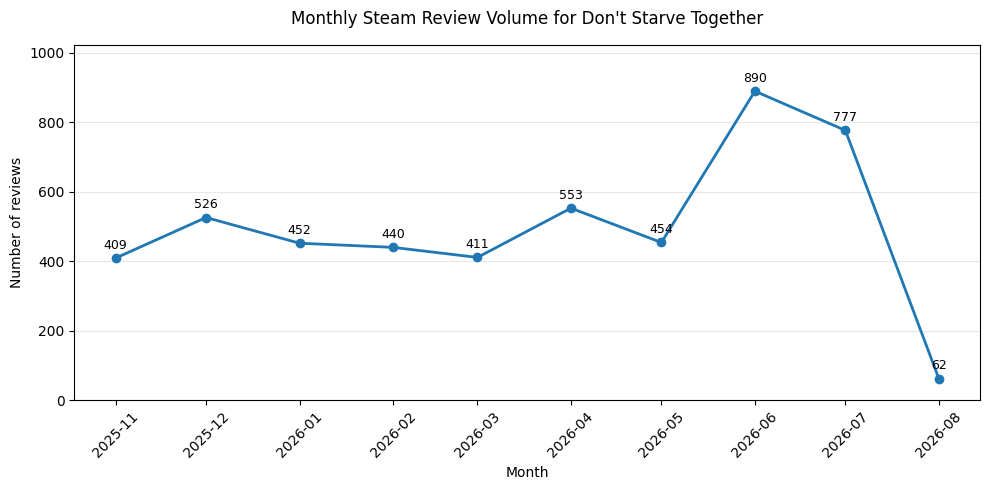

In [15]:
figure, axis = plt.subplots(figsize=(10, 5))

axis.plot(
    monthly_summary["review_month"],
    monthly_summary["review_count"],
    marker="o",
    linewidth=2,
)

axis.set_title(
    "Monthly Steam Review Volume for Don't Starve Together",
    pad=15,
)
axis.set_xlabel("Month")
axis.set_ylabel("Number of reviews")
axis.tick_params(
    axis="x",
    rotation=45,
)
axis.grid(
    axis="y",
    alpha=0.3,
)

maximum_count = monthly_summary["review_count"].max()

axis.set_ylim(
    0,
    maximum_count * 1.15,
)

for _, row in monthly_summary.iterrows():
    axis.text(
        row["review_month"],
        row["review_count"] + maximum_count * 0.02,
        str(int(row["review_count"])),
        ha="center",
        va="bottom",
        fontsize=9,
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "02_monthly_review_volume.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

数据集包含2025年11月25日至2026年8月5日之间的评论。其中2025年11月和2026年8月为不完整的月份。
在完整的月份中，2025年12月至2026年5月期间的评论数量相对稳定。随后在2026年6月显著增加至890条评论，并在2026年7月保持在777条评论的高位。目前无法确定这一增长的原因。

In [16]:
monthly_summary[
    [
        "review_month",
        "review_count",
        "positive_reviews",
        "positive_rate",
    ]
].assign(
    positive_rate=lambda data: (
        data["positive_rate"] * 100
    ).round(2)
)

,review_month,review_count,positive_reviews,positive_rate
0,2025-11-01,409,403,98.53
1,2025-12-01,526,477,90.68
2,2026-01-01,452,406,89.82
3,2026-02-01,440,394,89.55
4,2026-03-01,411,374,91.0
5,2026-04-01,553,504,91.14
6,2026-05-01,454,409,90.09
7,2026-06-01,890,800,89.89
8,2026-07-01,777,691,88.93
9,2026-08-01,62,54,87.1


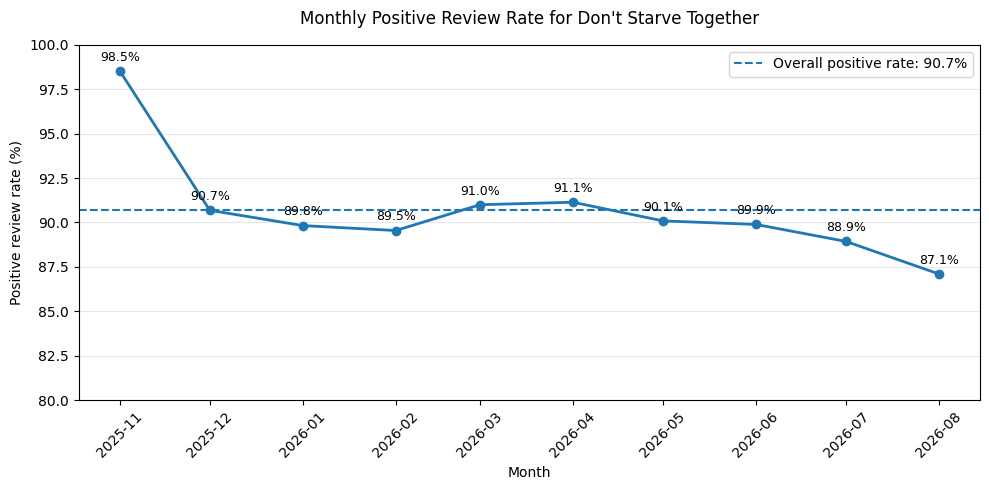

In [17]:
figure, axis = plt.subplots(figsize=(10, 5))

monthly_positive_rate = (
    monthly_summary["positive_rate"] * 100
)

axis.plot(
    monthly_summary["review_month"],
    monthly_positive_rate,
    marker="o",
    linewidth=2,
)

overall_positive_rate = (
    all_df["voted_up"].mean() * 100
)

axis.axhline(
    overall_positive_rate,
    linestyle="--",
    label=(
        f"Overall positive rate: "
        f"{overall_positive_rate:.1f}%"
    ),
)

axis.set_title(
    "Monthly Positive Review Rate for Don't Starve Together",
    pad=15,
)
axis.set_xlabel("Month")
axis.set_ylabel("Positive review rate (%)")
axis.tick_params(
    axis="x",
    rotation=45,
)
axis.grid(
    axis="y",
    alpha=0.3,
)

minimum_rate = monthly_positive_rate.min()
maximum_rate = monthly_positive_rate.max()

axis.set_ylim(80, 100)

for month, rate in zip(
    monthly_summary["review_month"],
    monthly_positive_rate,
):
    axis.text(
        month,
        rate + 0.4,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

axis.legend()

figure.tight_layout()

figure.savefig(
    figures_dir / "03_monthly_positive_rate.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

整体正面评价率为90.71%。在完整月份中，月度正面率保持在88.9%至91.1%之间相对稳定。
2026年4月，正面评价率达到了91.1%，随后逐渐下降至2026年7月的88.9%。6月和7月的评论量也显著增加。这一趋势表明，增长的评论活动中包含的比例更高的负面反馈。
2025年11月和2026年8月为不完整的月份，不应直接用于评估整体趋势。还需进一步的文本分析来探究近期下降的原因。

In [18]:
all_df["review_category"] = (
    all_df["voted_up"]
    .map(
        {
            True: "Recommended",
            False: "Not recommended",
        }
    )
)

all_df[
    [
        "voted_up",
        "review_category",
        "playtime_at_review_hours",
    ]
].head()

,voted_up,review_category,playtime_at_review_hours
0,False,Not recommended,4.416667
1,True,Recommended,260.350000
2,True,Recommended,8.583333
3,True,Recommended,4.450000
4,True,Recommended,26.066667


In [19]:
playtime_summary = (
    all_df.groupby(
        "review_category",
        observed=True,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        mean_playtime_hours=(
            "playtime_at_review_hours",
            "mean",
        ),
        median_playtime_hours=(
            "playtime_at_review_hours",
            "median",
        ),
        minimum_playtime_hours=(
            "playtime_at_review_hours",
            "min",
        ),
        percentile_25_hours=(
            "playtime_at_review_hours",
            lambda values: values.quantile(0.25),
        ),
        percentile_75_hours=(
            "playtime_at_review_hours",
            lambda values: values.quantile(0.75),
        ),
        percentile_90_hours=(
            "playtime_at_review_hours",
            lambda values: values.quantile(0.90),
        ),
        maximum_playtime_hours=(
            "playtime_at_review_hours",
            "max",
        ),
    )
    .reindex(
        [
            "Recommended",
            "Not recommended",
        ]
    )
)

playtime_summary.round(2)

,review_count,mean_playtime_hours,median_playtime_hours,minimum_playtime_hours,percentile_25_hours,percentile_75_hours,percentile_90_hours,maximum_playtime_hours
review_category,,,,,,,,
Recommended,4512,150.25,32.84,0.08,8.77,125.72,356.18,28341.55
Not recommended,462,65.19,7.79,0.12,1.97,30.89,123.55,4005.15


In [20]:
all_df[
    [
        "review_category",
        "playtime_at_review_hours",
        "review",
    ]
].sort_values(
    "playtime_at_review_hours",
    ascending=False,
).head(10)

,review_category,playtime_at_review_hours,review
653,Recommended,28341.550000,ok
4384,Recommended,20414.733333,Great game
1823,Recommended,8888.816667,"Played it a bit, its okay."
4945,Recommended,5261.450000,Great Game
3034,Recommended,4167.816667,"i started on xbox, and put 800 hours into that- and here we are, 6 years later. the game itself has been out for muc..."
330,Recommended,4090.050000,"My absolute favorite game of all time, sinked hundreds of hours into playing it.\n\nDon't Starve Together is the ult..."
4677,Recommended,4029.633333,Trying from don't starve to fighting the moon and shadow.\nHighly recommended! (10/10)
4599,Not recommended,4005.150000,"Alright, my review. Ignore that I have 1 teeny tiny bit extra hour on the game. I've reached 4000 hours on this game..."
2958,Recommended,3849.550000,"At first, I wasn’t very interested in Don’t Starve Together because the game’s colors were a bit overwhelming, makin..."
2715,Recommended,3797.233333,"One of the best games I've ever played, requires you to use imagination and just rewards you for curiosity, I LOVE T..."


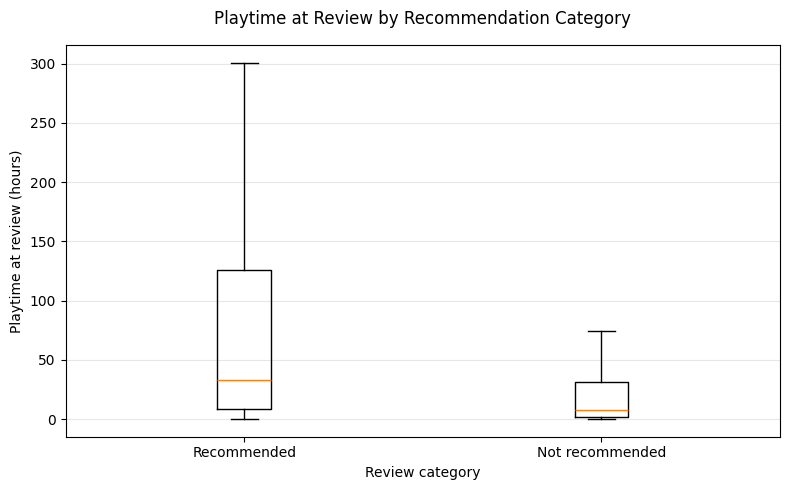

In [21]:
recommended_playtime = all_df.loc[
    all_df["voted_up"].eq(True),
    "playtime_at_review_hours",
].dropna()

not_recommended_playtime = all_df.loc[
    all_df["voted_up"].eq(False),
    "playtime_at_review_hours",
].dropna()

figure, axis = plt.subplots(figsize=(8, 5))

axis.boxplot(
    [
        recommended_playtime,
        not_recommended_playtime,
    ],
    tick_labels=[
        "Recommended",
        "Not recommended",
    ],
    showfliers=False,
)

axis.set_title(
    "Playtime at Review by Recommendation Category",
    pad=15,
)
axis.set_xlabel("Review category")
axis.set_ylabel("Playtime at review (hours)")
axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    figures_dir / "04_playtime_by_review_category.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [22]:
recommended_median = (
    playtime_summary.loc[
        "Recommended",
        "median_playtime_hours",
    ]
)

not_recommended_median = (
    playtime_summary.loc[
        "Not recommended",
        "median_playtime_hours",
    ]
)

median_difference = (
    not_recommended_median
    - recommended_median
)

print(
    "Recommended median playtime:",
    f"{recommended_median:.2f} hours",
)

print(
    "Not recommended median playtime:",
    f"{not_recommended_median:.2f} hours",
)

print(
    "Median difference:",
    f"{median_difference:.2f} hours",
)

Recommended median playtime: 32.84 hours
Not recommended median playtime: 7.79 hours
Median difference: -25.05 hours


In [23]:
recommended_median = playtime_summary.loc[
    "Recommended",
    "median_playtime_hours",
]

not_recommended_median = playtime_summary.loc[
    "Not recommended",
    "median_playtime_hours",
]

median_difference = (
    recommended_median - not_recommended_median
)

median_ratio = (
    recommended_median / not_recommended_median
)

print(
    f"Recommended median: "
    f"{recommended_median:.2f} hours"
)

print(
    f"Not recommended median: "
    f"{not_recommended_median:.2f} hours"
)

print(
    f"Median difference: "
    f"{median_difference:.2f} hours"
)

print(
    f"Median ratio: "
    f"{median_ratio:.2f}"
)

Recommended median: 32.84 hours
Not recommended median: 7.79 hours
Median difference: 25.05 hours
Median ratio: 4.21


推荐评论的平均游玩时长为32.84小时，而不推荐评论的平均游玩时长仅为7.79小时。正面评论者的平均游玩时长约为负面评论者的4.2倍。
50%的正面评价者在提交评论时，玩游戏的时间介于8.77至125.72小时之间。而负面评价者的相应时间范围为1.97至30.89小时。
这表明，负面反馈更常见于玩家体验的早期阶段。

In [24]:
review_length_summary = (
    all_df.groupby(
        "review_category",
        observed=True,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        mean_word_count=(
            "review_word_count",
            "mean",
        ),
        median_word_count=(
            "review_word_count",
            "median",
        ),
        percentile_25_words=(
            "review_word_count",
            lambda values: values.quantile(0.25),
        ),
        percentile_75_words=(
            "review_word_count",
            lambda values: values.quantile(0.75),
        ),
        percentile_90_words=(
            "review_word_count",
            lambda values: values.quantile(0.90),
        ),
        maximum_word_count=(
            "review_word_count",
            "max",
        ),
    )
    .reindex(
        [
            "Recommended",
            "Not recommended",
        ]
    )
)

review_length_summary.round(2)

,review_count,mean_word_count,median_word_count,percentile_25_words,percentile_75_words,percentile_90_words,maximum_word_count
review_category,,,,,,,
Recommended,4512,18.85,6.0,2.0,17.0,42.9,1087
Not recommended,462,44.24,13.0,4.0,42.0,97.0,1449


In [25]:
all_df[
    [
        "review_category",
        "review_word_count",
        "review",
    ]
].sort_values(
    "review_word_count",
    ascending=False,
).head(10)

,review_category,review_word_count,review
4089,Not recommended,1449,"DST is a game from a studio that well-earned it's ""indie darling"" status with a fun, fresh yet unforgiving title tha..."
4879,Recommended,1087,"An excellent game by an equally excellent team.\n\nThis is the only ""survival"" game I've played that has you actuall..."
2595,Not recommended,1039,"First, the positives. \n \nThe artstyle is unique, vibrant and gorgeous! Animations look smooth and everything is ..."
4741,Recommended,809,"A Critical Review of Don’t Starve: A Masterpiece of Survival Artistry\n\nIntroduction\nDon’t Starve, developed by Kl..."
428,Not recommended,701,"I know I haven't played much, but first impressions matter, and mine wasn't good.\n\nA friend and I picked up the ga..."
3560,Recommended,582,"After 1,000+ hours I realized something. \n\nDon't Starve Together is NOT a game. I repeat, NOT a game.\n\nIt is ins..."
4824,Recommended,539,I don't even know where to begin with this one. I've put even more hours factoring in offline and Don't Starve (the ...
955,Recommended,484,"[h3] Survive Together, Laugh Together, Die Together [/h3]\n\n[code] [quote=Wendrex] 🇺🇸 English\n\n🎮 Introduction\n\n..."
4599,Not recommended,476,"Alright, my review. Ignore that I have 1 teeny tiny bit extra hour on the game. I've reached 4000 hours on this game..."
4029,Recommended,448,"hate hounds, hate hounds, hate hounds, hate hounds, hate hounds, hate hounds, hate hounds, hate hounds, hate hounds,..."


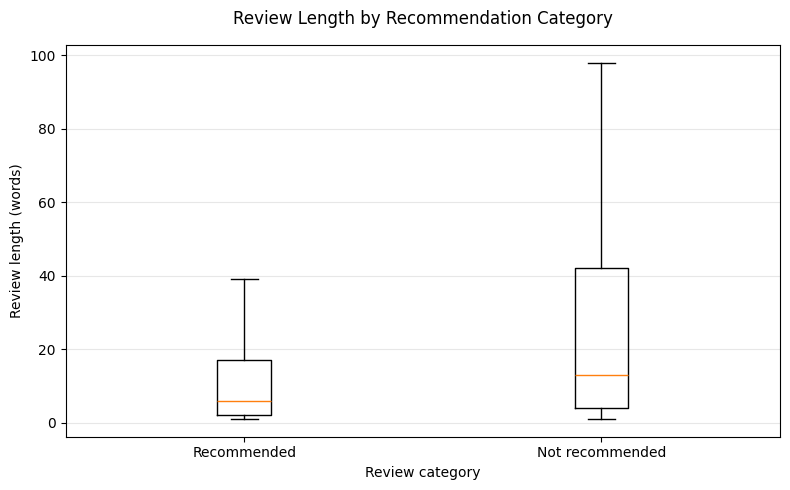

In [26]:
recommended_length = all_df.loc[
    all_df["voted_up"].eq(True),
    "review_word_count",
].dropna()

not_recommended_length = all_df.loc[
    all_df["voted_up"].eq(False),
    "review_word_count",
].dropna()

figure, axis = plt.subplots(figsize=(8, 5))

axis.boxplot(
    [
        recommended_length,
        not_recommended_length,
    ],
    tick_labels=[
        "Recommended",
        "Not recommended",
    ],
    showfliers=False,
)

axis.set_title(
    "Review Length by Recommendation Category",
    pad=15,
)
axis.set_xlabel("Review category")
axis.set_ylabel("Review length (words)")
axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    figures_dir / "05_review_length_by_category.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [27]:
recommended_length_median = review_length_summary.loc[
    "Recommended",
    "median_word_count",
]

negative_length_median = review_length_summary.loc[
    "Not recommended",
    "median_word_count",
]

length_difference = (
    negative_length_median
    - recommended_length_median
)

print(
    f"Recommended median length: "
    f"{recommended_length_median:.2f} words"
)

print(
    f"Not recommended median length: "
    f"{negative_length_median:.2f} words"
)

print(
    f"Median difference: "
    f"{length_difference:.2f} words"
)

Recommended median length: 6.00 words
Not recommended median length: 13.00 words
Median difference: 7.00 words


In [28]:
print(
    all_df["review_length_category"]
    .value_counts(dropna=False)
)

review_length_category
Very short    2231
Short         1611
Medium         679
Long           261
Very long      192
Name: count, dtype: int64


In [29]:
length_category_summary = pd.crosstab(
    all_df["review_length_category"],
    all_df["review_category"],
)

length_category_summary

review_category,Not recommended,Recommended
review_length_category,,
Long,51,210
Medium,99,580
Short,129,1482
Very long,43,149
Very short,140,2091


In [30]:
length_positive_rate = (
    all_df.groupby(
        "review_length_category",
        observed=True,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        positive_rate=(
            "voted_up",
            "mean",
        ),
    )
)

length_positive_rate["positive_rate"] = (
    length_positive_rate["positive_rate"] * 100
).round(2)

length_positive_rate

,review_count,positive_rate
review_length_category,,
Long,261,80.46
Medium,679,85.42
Short,1611,91.99
Very long,192,77.6
Very short,2231,93.72


不推荐的评论通常比推荐的评论更长。负面评论的中位数为13个词，而正面评论的中位数为6个词。负面评论的中位长度大约是正面评论的2.17倍。
正面评价中，50%的评论字数在2到17个之间，而负面评价对应的字数范围为4到42个。这表明不满意的玩家往往更倾向于提供详细的文字反馈。

In [31]:
length_order = [
    "Very short",
    "Short",
    "Medium",
    "Long",
    "Very long",
]

all_df["review_length_category"].value_counts(
    dropna=False
).reindex(length_order)

review_length_category
Very short    2231
Short         1611
Medium         679
Long           261
Very long      192
Name: count, dtype: int64

In [32]:
length_positive_rate = (
    all_df.groupby(
        "review_length_category",
        observed=True,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        positive_reviews=(
            "voted_up",
            "sum",
        ),
        positive_rate=(
            "voted_up",
            "mean",
        ),
    )
    .reindex(length_order)
)

length_positive_rate_display = (
    length_positive_rate.copy()
)

length_positive_rate_display["positive_rate"] = (
    length_positive_rate_display["positive_rate"]
    * 100
).round(2)

length_positive_rate_display

,review_count,positive_reviews,positive_rate
review_length_category,,,
Very short,2231,2091,93.72
Short,1611,1482,91.99
Medium,679,580,85.42
Long,261,210,80.46
Very long,192,149,77.6


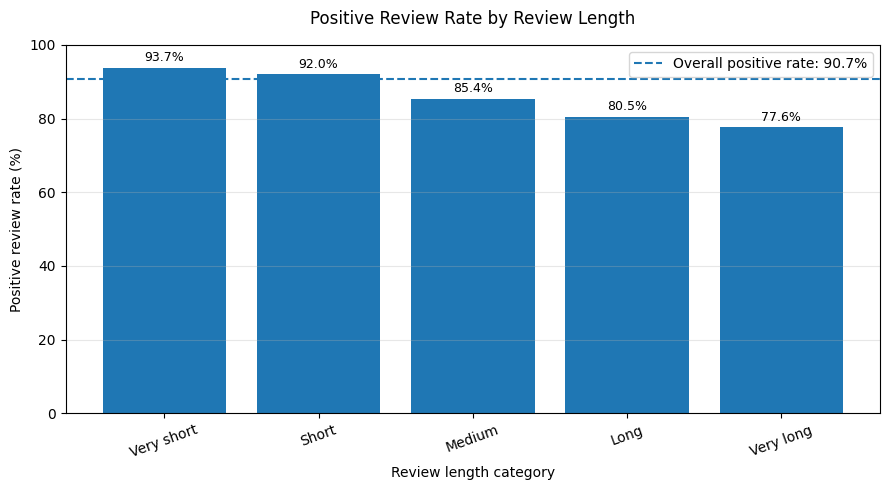

In [33]:
figure, axis = plt.subplots(figsize=(9, 5))

positive_rates = (
    length_positive_rate["positive_rate"] * 100
)

bars = axis.bar(
    length_positive_rate.index,
    positive_rates,
)

overall_positive_rate = (
    all_df["voted_up"].mean() * 100
)

axis.axhline(
    overall_positive_rate,
    linestyle="--",
    label=(
        f"Overall positive rate: "
        f"{overall_positive_rate:.1f}%"
    ),
)

axis.set_title(
    "Positive Review Rate by Review Length",
    pad=15,
)
axis.set_xlabel("Review length category")
axis.set_ylabel("Positive review rate (%)")
axis.set_ylim(0, 100)
axis.tick_params(
    axis="x",
    rotation=20,
)
axis.grid(
    axis="y",
    alpha=0.3,
)

for bar, rate in zip(bars, positive_rates):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

axis.legend()

figure.tight_layout()

figure.savefig(
    figures_dir / "06_positive_rate_by_review_length.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

正面评价率随着评论长度的增加而持续下降。非常简短的评论正面率为93.7%，而非常长的评论正面率为77.6%，两者相差16.1个百分点。
这一结果与之前的研究发现一致，即负面评论通常比正面评论更长。不满意的玩家可能会用更多词语来描述问题或解释自己的体验，而满意的玩家则往往只留下简短的推荐。
不过需要注意，这种关系是关联性的而不是因果性的。评论长度本身并不会导致评论成为负面的。

In [34]:
all_df["has_helpful_vote"] = (
    all_df["votes_up"] > 0
)

In [35]:
helpful_summary = (
    all_df.groupby(
        "review_category",
        observed=True,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        mean_helpful_votes=(
            "votes_up",
            "mean",
        ),
        median_helpful_votes=(
            "votes_up",
            "median",
        ),
        percentile_90_votes=(
            "votes_up",
            lambda values: values.quantile(0.90),
        ),
        maximum_helpful_votes=(
            "votes_up",
            "max",
        ),
        reviews_with_helpful_votes=(
            "has_helpful_vote",
            "sum",
        ),
        helpful_vote_rate=(
            "has_helpful_vote",
            "mean",
        ),
    )
    .reindex(
        [
            "Recommended",
            "Not recommended",
        ]
    )
)

helpful_summary_display = helpful_summary.copy()

helpful_summary_display["helpful_vote_rate"] = (
    helpful_summary_display["helpful_vote_rate"]
    * 100
).round(2)

helpful_summary_display.round(2)

,review_count,mean_helpful_votes,median_helpful_votes,percentile_90_votes,maximum_helpful_votes,reviews_with_helpful_votes,helpful_vote_rate
review_category,,,,,,,
Recommended,4512,0.59,0.0,1.0,496,627,13.90
Not recommended,462,0.95,0.0,2.0,18,178,38.53


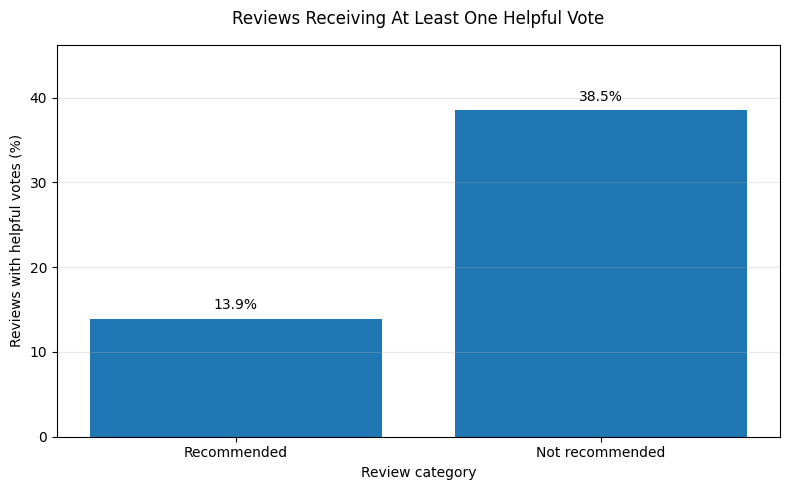

In [36]:
helpful_vote_rates = (
    helpful_summary["helpful_vote_rate"] * 100
)

figure, axis = plt.subplots(figsize=(8, 5))

bars = axis.bar(
    helpful_vote_rates.index,
    helpful_vote_rates.values,
)

axis.set_title(
    "Reviews Receiving At Least One Helpful Vote",
    pad=15,
)
axis.set_xlabel("Review category")
axis.set_ylabel("Reviews with helpful votes (%)")
axis.set_ylim(
    0,
    helpful_vote_rates.max() * 1.2,
)
axis.grid(
    axis="y",
    alpha=0.3,
)

for bar, rate in zip(
    bars,
    helpful_vote_rates.values,
):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()
        + helpful_vote_rates.max() * 0.02,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "07_helpful_vote_rate_by_category.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

不推荐的评论获得有用投票的可能性要高得多。大约38.5%的负面评论至少获得了一次有用投票，而正面评论仅为13.9%，两者之间的差距为24.6个百分点。
负面评论的平均长度也更长，因此其较高的有用投票率可能部分反映了它们提供的细节更多。然而，有用投票也可能受到评论年龄和可见度的影响。因此，这一结果表明的是相关性而非因果关系。

In [37]:
print("Steam purchase distribution")

display(
    all_df["steam_purchase"]
    .value_counts(dropna=False)
    .to_frame("review_count")
)

print("Received for free distribution")

display(
    all_df["received_for_free"]
    .value_counts(dropna=False)
    .to_frame("review_count")
)

Steam purchase distribution


,review_count
steam_purchase,
True,3408
False,1566


Received for free distribution


,review_count
received_for_free,
False,4808
True,166


In [38]:
steam_purchase_summary = (
    all_df.groupby(
        "steam_purchase",
        dropna=False,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        positive_reviews=(
            "voted_up",
            "sum",
        ),
        positive_rate=(
            "voted_up",
            "mean",
        ),
        median_playtime_hours=(
            "playtime_at_review_hours",
            "median",
        ),
        median_word_count=(
            "review_word_count",
            "median",
        ),
    )
)

steam_purchase_display = steam_purchase_summary.copy()

steam_purchase_display["positive_rate"] = (
    steam_purchase_display["positive_rate"] * 100
).round(2)

steam_purchase_display.round(2)

,review_count,positive_reviews,positive_rate,median_playtime_hours,median_word_count
steam_purchase,,,,,
False,1566,1409,89.97,28.67,6.0
True,3408,3103,91.05,29.90,7.0


In [39]:
free_summary = (
    all_df.groupby(
        "received_for_free",
        dropna=False,
    )
    .agg(
        review_count=(
            "recommendation_id",
            "count",
        ),
        positive_reviews=(
            "voted_up",
            "sum",
        ),
        positive_rate=(
            "voted_up",
            "mean",
        ),
        median_playtime_hours=(
            "playtime_at_review_hours",
            "median",
        ),
        median_word_count=(
            "review_word_count",
            "median",
        ),
    )
)

free_summary_display = free_summary.copy()

free_summary_display["positive_rate"] = (
    free_summary_display["positive_rate"] * 100
).round(2)

free_summary_display.round(2)

,review_count,positive_reviews,positive_rate,median_playtime_hours,median_word_count
received_for_free,,,,,
False,4808,4360,90.68,29.72,7.0
True,166,152,91.57,21.64,8.0


标记为Steam购买的评论正面评价率为91.05%，而未标记为Steam购买的评论正面评价率为89.97%，两者仅相差1.08个百分点，同时中位游玩时长和评论长度也相近。
收到游戏免费的用户评价中，正面比例为91.57%，而其他用户的正面比例为90.68%。然而，仅有166条评价被标记为免费获得，差距不到一个百分点。
这些结果表明，在该样本中，购买状态以及免费获得游戏并非影响推荐行为的主要因素。

In [40]:
tables_dir = project_root / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

review_distribution.to_csv(
    tables_dir / "review_distribution.csv",
    header=["review_count"],
)

monthly_summary.to_csv(
    tables_dir / "monthly_summary.csv",
    index=False,
)

playtime_summary.to_csv(
    tables_dir / "playtime_by_review_category.csv",
)

review_length_summary.to_csv(
    tables_dir / "review_length_by_category.csv",
)

length_positive_rate.to_csv(
    tables_dir / "positive_rate_by_review_length.csv",
)

helpful_summary.to_csv(
    tables_dir / "helpful_votes_by_category.csv",
)

steam_purchase_summary.to_csv(
    tables_dir / "steam_purchase_summary.csv",
)

free_summary.to_csv(
    tables_dir / "received_for_free_summary.csv",
)

print("Summary tables saved to:", tables_dir)

Summary tables saved to: /Users/zhouzhou/Desktop/dst-review-analysis/outputs/tables


In [41]:
sorted(
    path.name
    for path in tables_dir.glob("*.csv")
)

['final_model_negative_features.csv',
 'final_model_positive_features.csv',
 'helpful_votes_by_category.csv',
 'logistic_regression_report.csv',
 'misclassified_negative_reviews.csv',
 'misclassified_positive_reviews.csv',
 'model_comparison.csv',
 'model_negative_features.csv',
 'model_positive_features.csv',
 'monthly_summary.csv',
 'negative_distinctive_bigrams.csv',
 'negative_distinctive_words.csv',
 'negative_top_words_initial.csv',
 'playtime_by_review_category.csv',
 'positive_distinctive_bigrams.csv',
 'positive_distinctive_words.csv',
 'positive_rate_by_review_length.csv',
 'positive_top_words_initial.csv',
 'received_for_free_summary.csv',
 'review_distribution.csv',
 'review_length_by_category.csv',
 'review_theme_summary.csv',
 'steam_purchase_summary.csv']